# Pumps and pipe networks

This tutorial fits a pump curve to catalogue data, finds its operating point, and then solves a
complete looped network containing a pump, several demands and two reservoirs.

In [1]:
try:
    import fluidmech
except ImportError:  # e.g. on Google Colab
    %pip install -q git+https://github.com/ktwyw/fluidmech.git
    import fluidmech
print("fluidmech", fluidmech.__version__)

fluidmech 0.3.0


In [2]:
import matplotlib.pyplot as plt
from fluidmech import Fluid, Network, PumpCurve
from fluidmech import pumps
from fluidmech import pipe_flow as pf
water = Fluid.water(15)

## 1. Pump curve from catalogue points

Manufacturers publish head and efficiency at a few flow rates. `PumpCurve.from_points` fits
quadratics $H = h_0 + h_1 Q + h_2 Q^2$ and $\eta = e_0 + e_1 Q + e_2 Q^2$.

In [3]:
pump = PumpCurve.from_points(
    flow_rates=[0.0, 0.04, 0.08, 0.12],
    heads=[42.0, 40.0, 33.5, 22.5],
    efficiencies=[0.0, 0.62, 0.80, 0.68],
)
print(f"Best efficiency point: {pump.best_efficiency_point()*1000:.1f} L/s")

Best efficiency point: 84.0 L/s


## 2. Operating point

The system needs $H_{sys}(Q) = H_{static} + h_L(Q)$. The pump settles where its curve crosses
the system curve.

Q = 101.7 L/s, H = 28.1 m, efficiency 78.7%, shaft power 35.6 kW


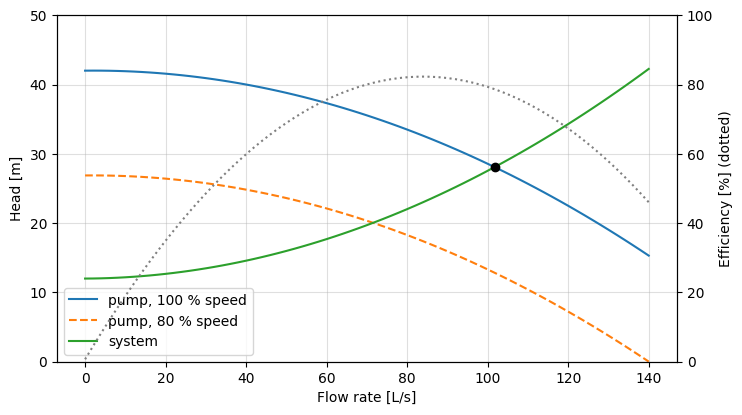

In [4]:
system = pumps.system_curve(static_head=12.0, diameter=0.25, length=800, fluid=water,
                            roughness=pf.ROUGHNESS["cast_iron"], k_total=8.0)
op = pumps.operating_point(pump, system, water.density)
print(f"Q = {op.flow_rate*1000:.1f} L/s, H = {op.head:.1f} m, efficiency {op.efficiency:.1%}, "
      f"shaft power {op.shaft_power/1e3:.1f} kW")

qs = [i / 1000 for i in range(0, 141, 2)]
fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot([q*1000 for q in qs], [pump.head(q) for q in qs], label="pump, 100 % speed")
ax1.plot([q*1000 for q in qs], [pump.scaled(speed_ratio=0.8).head(q) for q in qs], "--", label="pump, 80 % speed")
ax1.plot([q*1000 for q in qs], [system(q) for q in qs], label="system")
ax1.plot(op.flow_rate*1000, op.head, "ko")
ax1.set_xlabel("Flow rate [L/s]"); ax1.set_ylabel("Head [m]"); ax1.set_ylim(0, 50); ax1.grid(alpha=0.4)
ax2 = ax1.twinx()
ax2.plot([q*1000 for q in qs], [max(pump.efficiency(q), 0) * 100 for q in qs], ":", color="grey")
ax2.set_ylabel("Efficiency [%] (dotted)"); ax2.set_ylim(0, 100)
ax1.legend(loc="lower left"); plt.show()

## 3. A looped network

`Network` solves the energy equation in every link and continuity at every junction
simultaneously with Newton's method (the method used by EPANET). No loops need to be defined.

```
  Works --pump--> J1 ------ J2 ------ J3
                  |          |         |
                  J4 ------ J5 ------ J6 ---- Tank
```

In [5]:
net = Network(water)
net.add_reservoir("Works", head=102.0)
net.add_reservoir("Tank", head=148.0)
for name, z, q_ls in [("PS", 100, 0), ("J1", 104, 8), ("J2", 108, 12), ("J3", 112, 10),
                      ("J4", 103, 25), ("J5", 106, 30), ("J6", 115, 9)]:
    net.add_junction(name, elevation=z, demand=q_ls / 1000)
net.add_pump("Pump", "Works", "PS", PumpCurve.from_points([0, 0.05, 0.10, 0.15], [68, 65, 56, 40]))
eps = pf.ROUGHNESS["cast_iron"]
for name, a, b, L, D in [("P0", "PS", "J1", 200, 0.35), ("P1", "J1", "J2", 500, 0.25),
                         ("P2", "J2", "J3", 450, 0.20), ("P3", "J1", "J4", 400, 0.30),
                         ("P4", "J2", "J5", 400, 0.20), ("P5", "J3", "J6", 400, 0.15),
                         ("P6", "J4", "J5", 500, 0.25), ("P7", "J5", "J6", 450, 0.20),
                         ("P8", "J6", "Tank", 300, 0.20)]:
    net.add_pipe(name, a, b, L, D, eps)
result = net.solve()
print(result.summary())

Converged in 5 iterations (max continuity error 6.9e-18 m3/s)

Link          Q [L/s]   V [m/s]   h_L [m]
Pump          116.335      pump   -51.403
P0            116.335     1.209     0.820
P1             45.575     0.928     1.860
P2             18.963     0.604     0.963
P3             62.761     0.888     1.088
P4             14.611     0.465     0.519
P5              8.963     0.507     0.880
P6             37.761     0.769     1.292
P7             22.372     0.712     1.324
P8             22.335     0.711     0.880

Node         Head [m]   p [kPa]
PS            153.403    523.25
J1            152.583    476.02
J2            150.722    418.60
J3            149.760    369.97
J4            151.495    475.16
J5            150.203    433.11
J6            148.880    331.96
Works         102.000   (fixed)
Tank          148.000   (fixed)


## 4. Service pressures

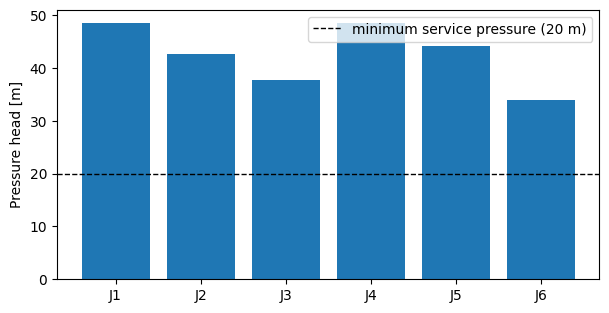

Tank is filling at 22.3 L/s


In [6]:
nodes = [n for n in result.pressures if n != "PS"]
heads = [result.pressures[n] / (water.density * 9.80665) for n in nodes]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(nodes, heads, color=["tab:red" if h < 20 else "tab:blue" for h in heads])
ax.axhline(20, color="k", ls="--", lw=1, label="minimum service pressure (20 m)")
ax.set_ylabel("Pressure head [m]"); ax.legend(); plt.show()
print("Tank is", "filling" if result.reservoir_outflows["Tank"] < 0 else "draining",
      f"at {abs(result.reservoir_outflows['Tank'])*1000:.1f} L/s")